In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("homeprices_banglore.csv")
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
from sklearn.preprocessing import MinMaxScaler

# Inputs and output
X = df[['area', 'bedrooms']]
y = df[['price']]

# Two separate scalers
feature_scaler = MinMaxScaler()
price_scaler = MinMaxScaler()

# Scale data
X_scaled = feature_scaler.fit_transform(X)
y_scaled = price_scaler.fit_transform(y.values.reshape(df.shape[0],1))

print(feature_scaler.n_features_in_)  # must print 2

2


In [4]:
y_scaled.reshape(20,)

array([0.05237037, 0.65185185, 0.22222222, 0.31851852, 0.14074074,
       0.04444444, 0.76296296, 0.91111111, 0.13333333, 1.        ,
       0.37037037, 0.8       , 0.04444444, 0.05925926, 0.51111111,
       0.07407407, 0.11851852, 0.20740741, 0.51851852, 0.        ])

In [5]:
def batch_gradient_descent(X, y_true, epochs, learning_rate = 0.01):

    number_of_features = X.shape[1]
    # numpy array with 1 row and columns equal to number of features. In 
    # our case number_of_features = 2 (area, bedroom)
    w = np.ones(shape=(number_of_features)) 
    b = 0
    total_samples = X.shape[0] # number of rows in X
    
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):        
        y_predicted = np.dot(w, X.T) + b

        w_grad = -(2/total_samples)*(X.T.dot(y_true-y_predicted))
        b_grad = -(2/total_samples)*np.sum(y_true-y_predicted)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.mean(np.square(y_true-y_predicted)) # MSE (Mean Squared Error)
        
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list

w, b, cost, cost_list, epoch_list = batch_gradient_descent(X_scaled,y_scaled.reshape(y_scaled.shape[0],),500)
w, b, cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407422),
 np.float64(0.0068641890429808105))

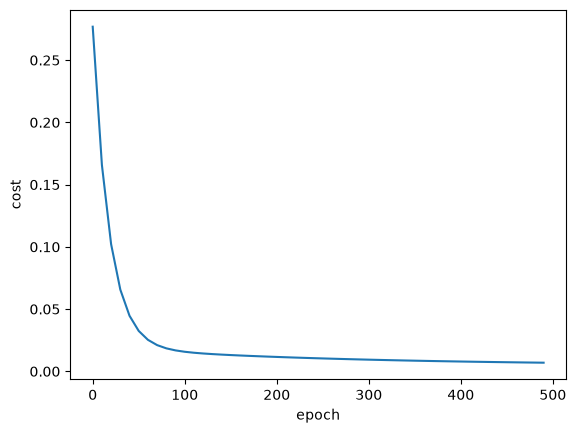

In [6]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [7]:
# def predict(area,bedrooms,w,b):
#     X_scaled = sx.transform([[area, bedrooms]])[0]
#     # here w1 = w[0] , w2 = w[1], w3 = w[2] and bias is b
#     # equation for price is w1*area + w2*bedrooms + w3*age + bias
#     # scaled_X[0] is area
#     # scaled_X[1] is bedrooms
#     # scaled_X[2] is age
#     scaled_price = w[0] * scaled_X[0] + w[1] * scaled_X[1] + b
#     # once we get price prediction we need to to rescal it back to original value
#     # also since it returns 2D array, to get single value we need to do value[0][0]
#     return sy.inverse_transform([[scaled_price]])[0][0]

# predict(2600,4,w,b)

def predict(area, bedrooms, w, b):
    X_scaled = feature_scaler.transform([[area, bedrooms]])[0]

    scaled_price = w[0] * X_scaled[0] + w[1] * X_scaled[1] + b

    return price_scaler.inverse_transform([[scaled_price]])[0][0]

In [8]:
predict(1000,2,w,b)

C:\Users\Mohd Zaid\anaconda3\envs\deep-learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(30.253094462442363)

Stochastic Gradient Descent Implementation

In [9]:
import random
def stochastic_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
 
    number_of_features = X.shape[1]
    # numpy array with 1 row and columns equal to number of features. In 
    # our case number_of_features = 3 (area, bedroom and age)
    w = np.ones(shape=(number_of_features)) 
    b = 0
    total_samples = X.shape[0]
    
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):    
        random_index = random.randint(0,total_samples-1) # random index from total samples
        sample_x = X[random_index]
        sample_y = y_true[random_index]
        
        y_predicted = np.dot(w, sample_x.T) + b
    
        w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
        b_grad = -(2/total_samples)*(sample_y-y_predicted)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.square(sample_y-y_predicted)
        
        if i%100==0: # at every 100th iteration record the cost and epoch value
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list

w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(
    X_scaled,
    y_scaled.reshape(y_scaled.shape[0]),
    10000
)
w_sgd, b_sgd, cost_sgd

(array([0.7061466 , 0.67579017]),
 np.float64(-0.2309249905287522),
 np.float64(0.0012983799107067627))

In [10]:
w , b 

(array([0.70712464, 0.67456527]), np.float64(-0.23034857438407422))

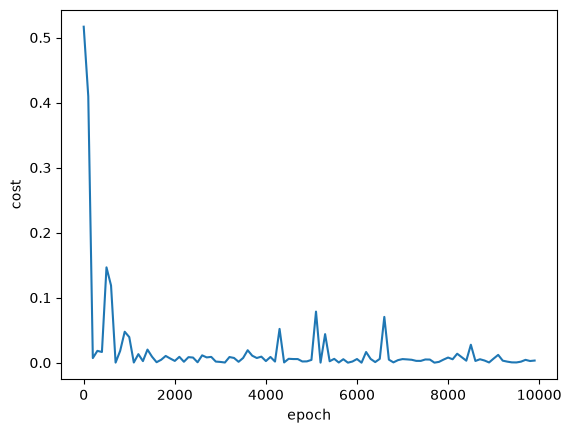

In [11]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)

In [12]:
predict(2600,4,w_sgd, b_sgd) 

C:\Users\Mohd Zaid\anaconda3\envs\deep-learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.4190957044618)